In [51]:
## Лабораторная работа номер 1

## Выполнил: Косолапов Павел Евгеньевич
## Группа: 2303

In [52]:
# установка matplotlib (версия должна быть выше 3.4)
!pip install matplotlib --upgrade

In [53]:
## импортируем все необходимые элементы
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import FormatStrFormatter

In [54]:

## 2. Загружаем данные

## Датасет содержит данные о характеристиках клеток из биопсии молочной железы.  
## Задача: классификация опухоли (M - malignant/злокачественная, B - benign/доброкачественная).  
## Источник: UCI Machine Learning Repository.



In [55]:
columns = ['ID', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
           'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 
           'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 
           'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 
           'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 
           'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 
           'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

# Загрузка по прямой ссылке
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'
df = pd.read_csv(url, header=None, names=columns)
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [56]:
## DataFrame успушно загружен и сохранен в df. Теперь можно перейти к анализу.

In [57]:
df.describe()

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [58]:
## Из таблицы видно, что данные чистые, с умеренными выбросами (большие max в '_worst' признаках), и классы слегка несбалансированы.
## Так же можно отметить что выбросы есть практически в всех атрибутах.

In [59]:
## 3. Одномерный анализ данных
## Посмотрим распределение числовых признаков (все, кроме ID и diagnosis).

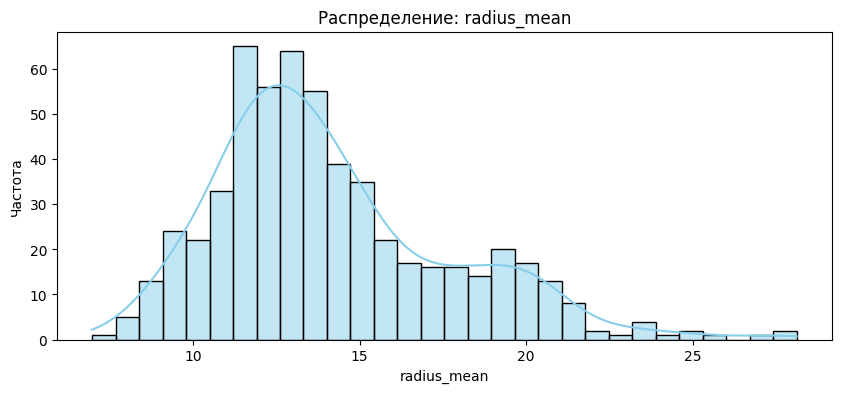

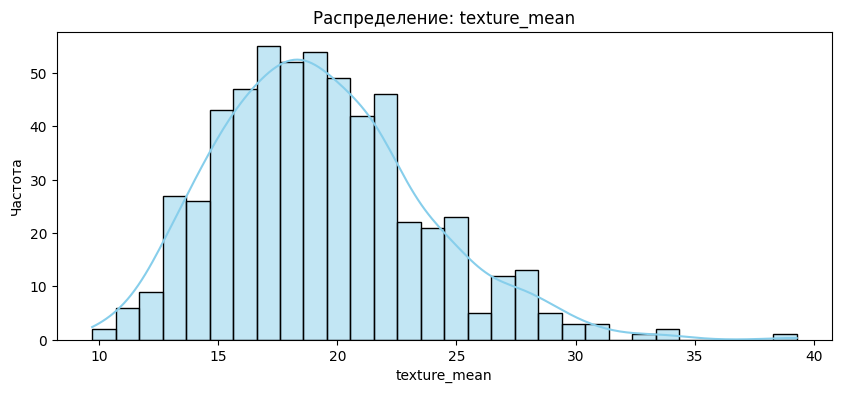

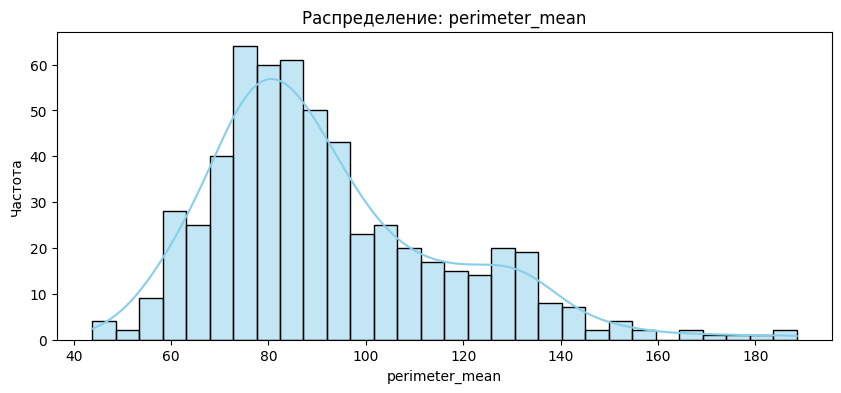

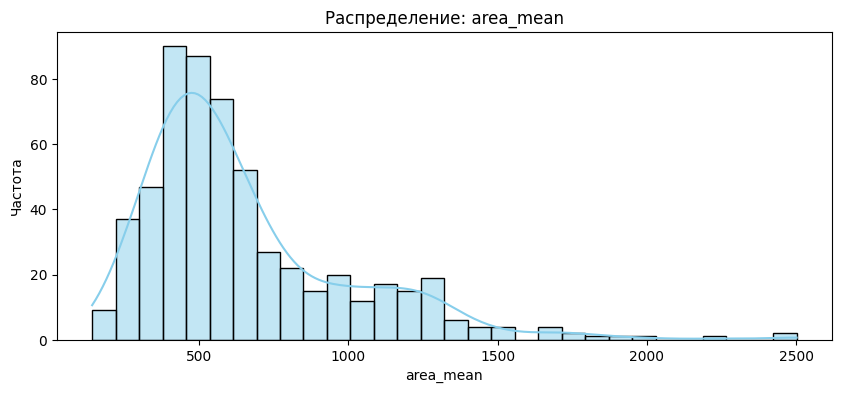

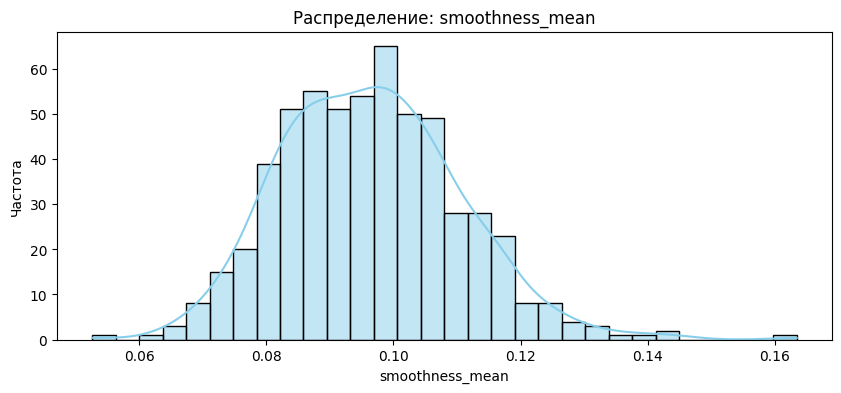

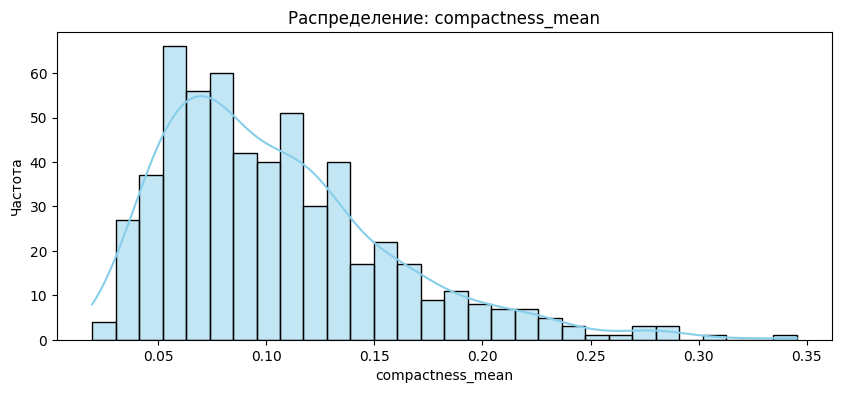

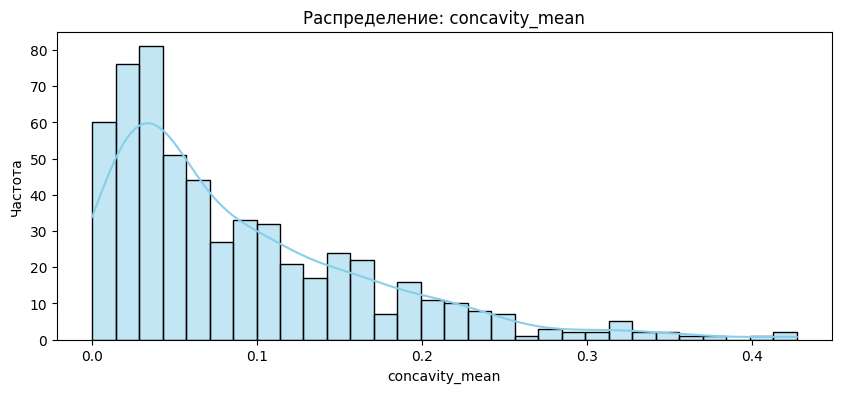

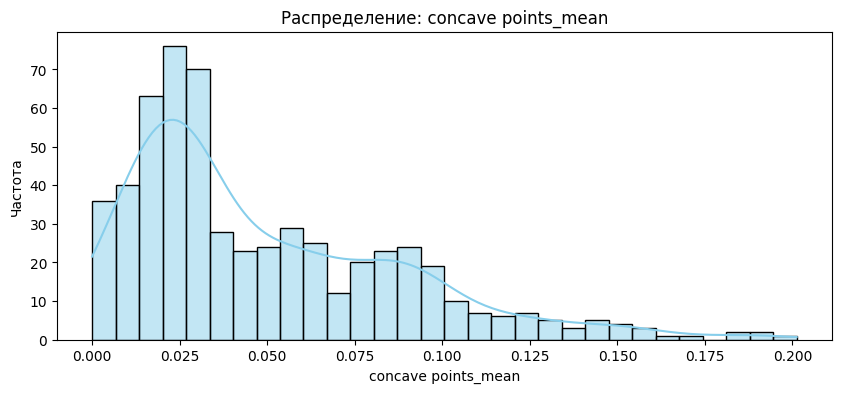

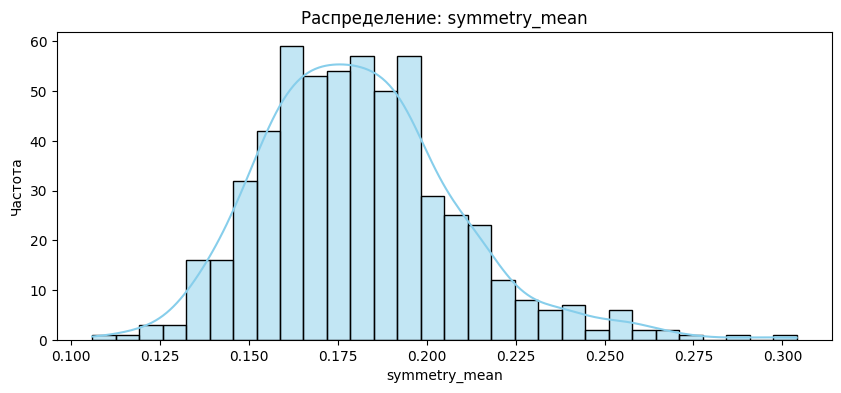

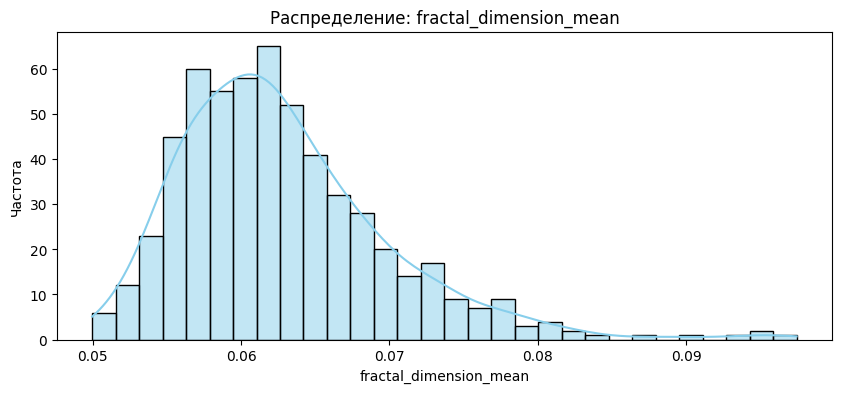

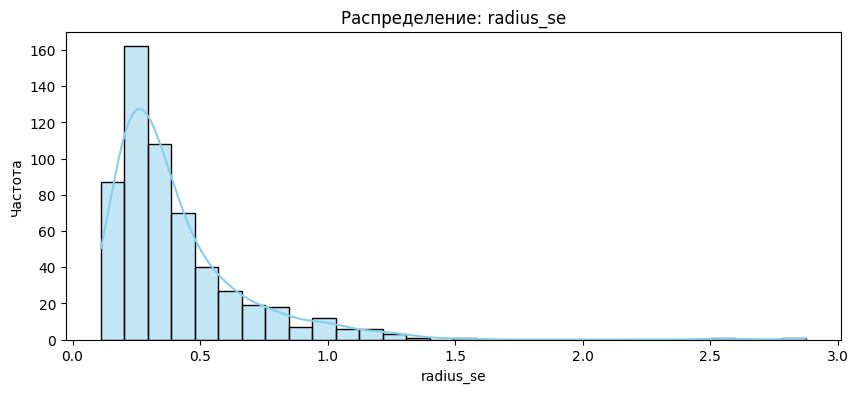

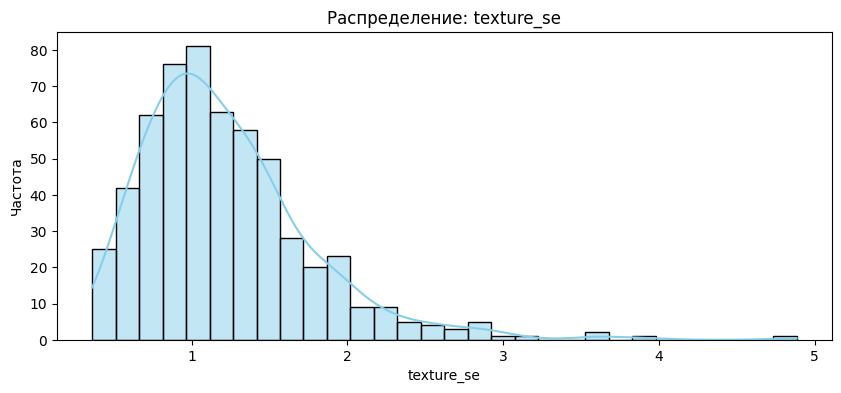

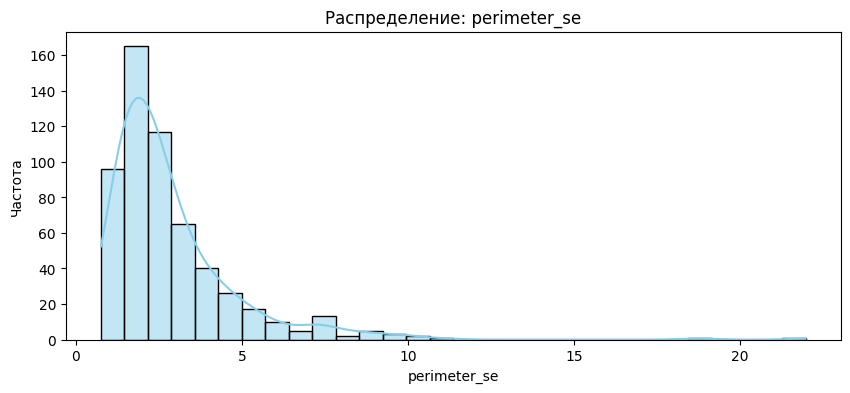

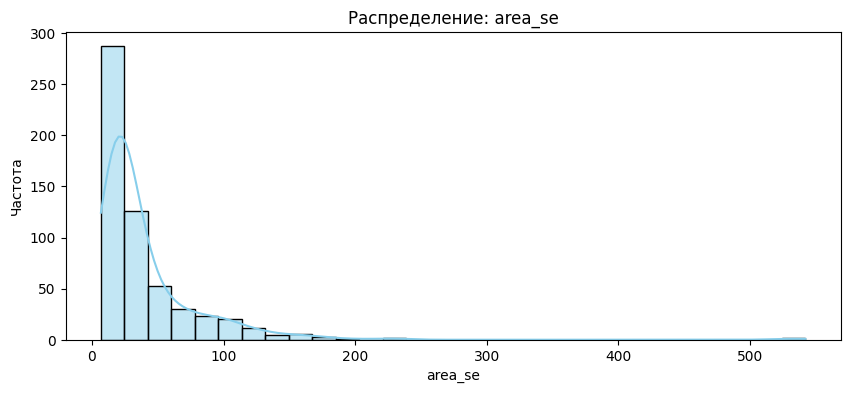

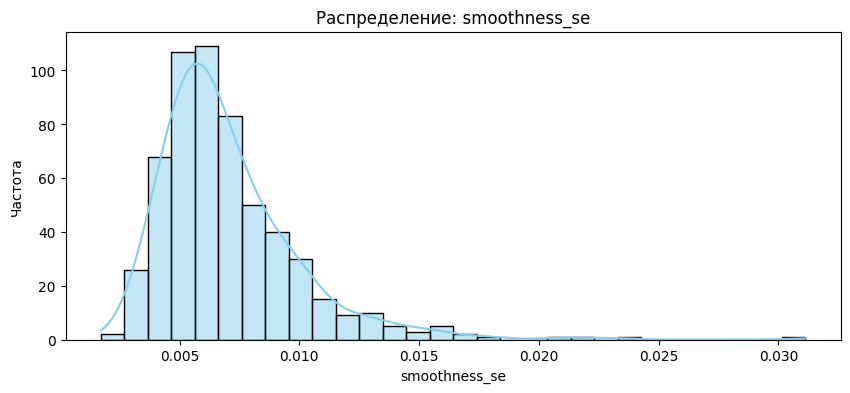

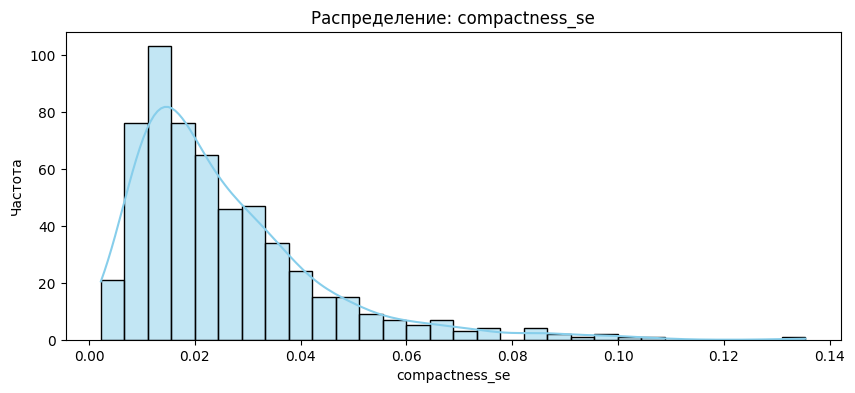

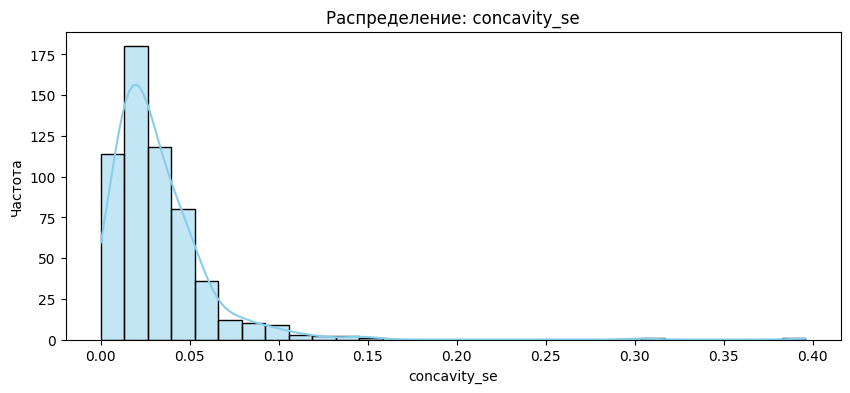

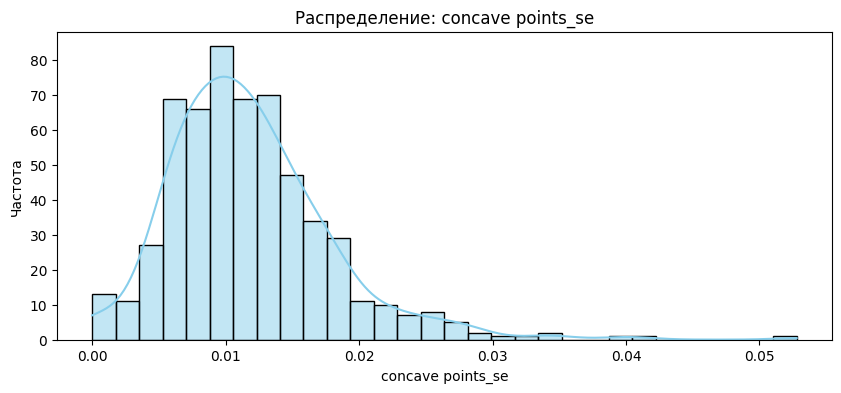

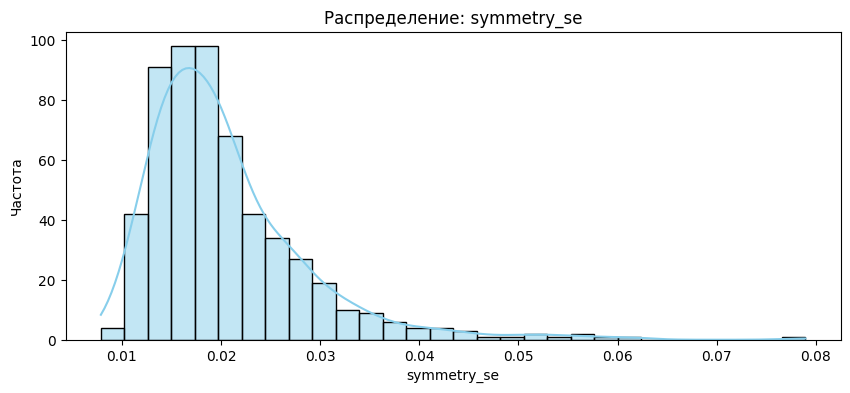

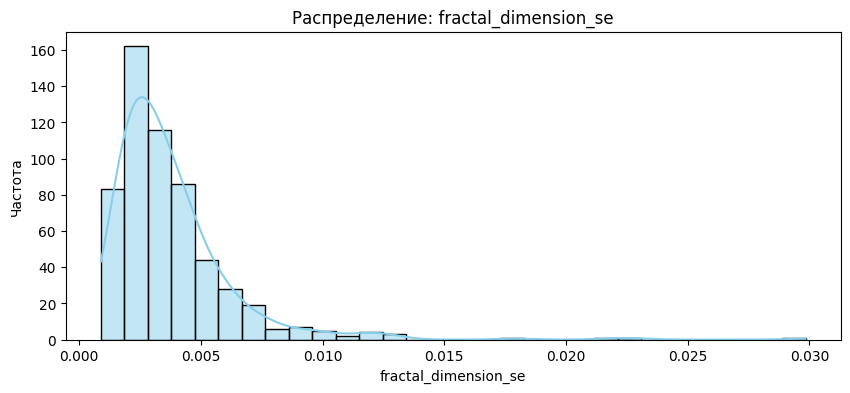

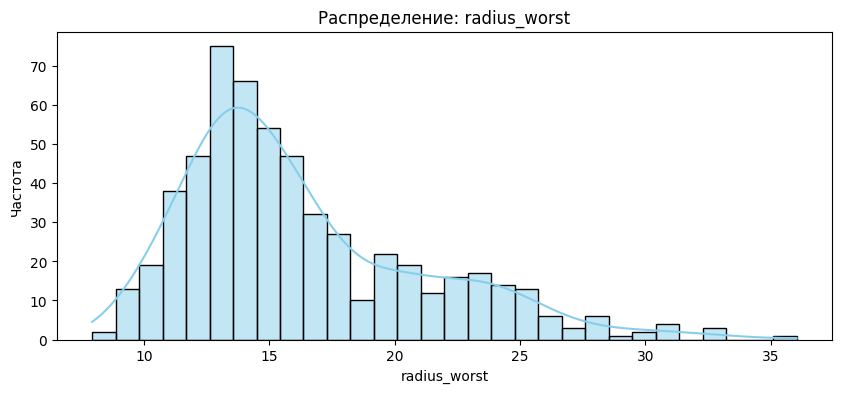

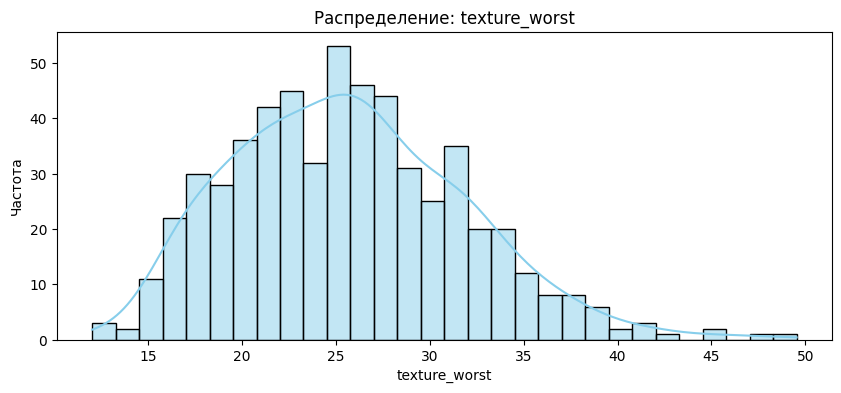

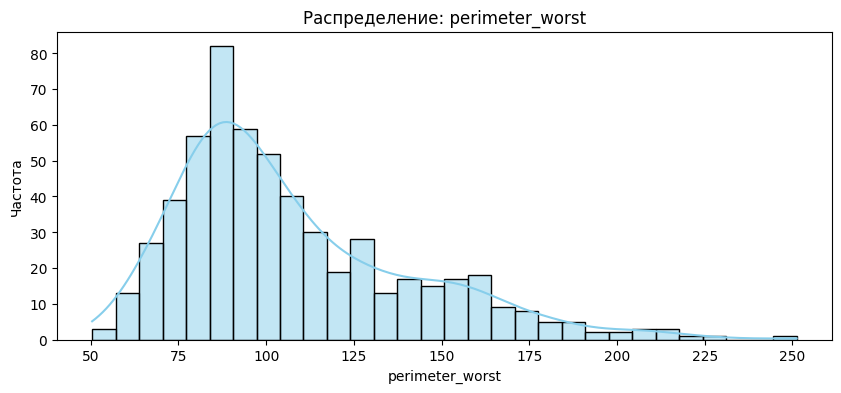

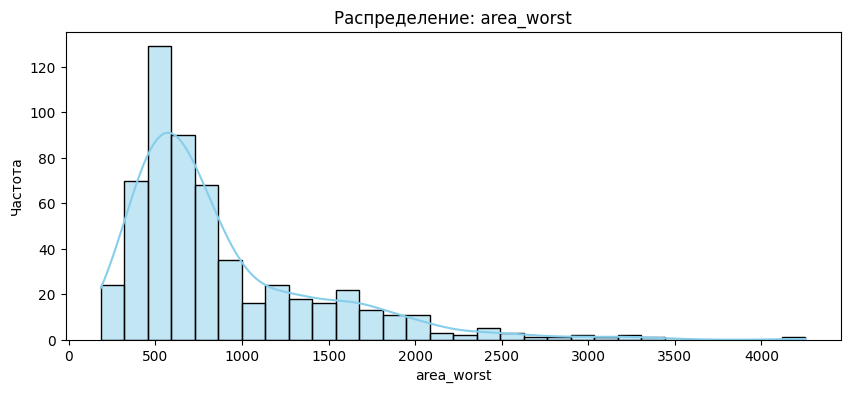

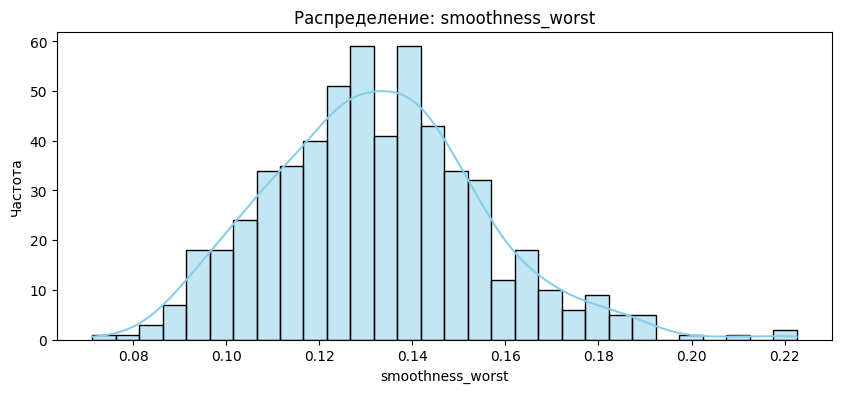

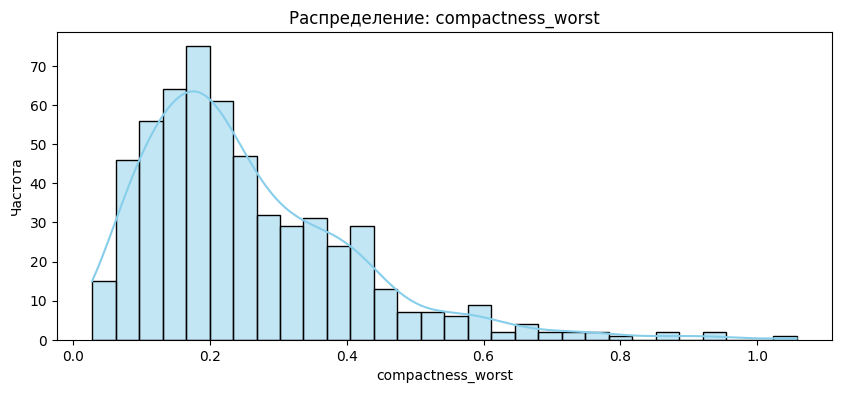

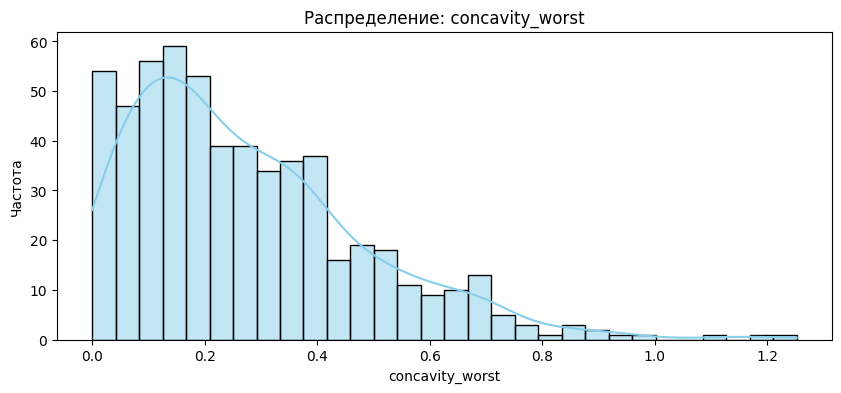

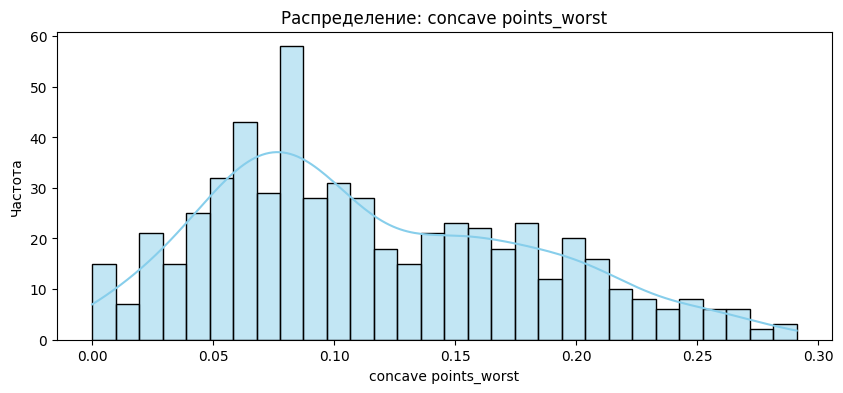

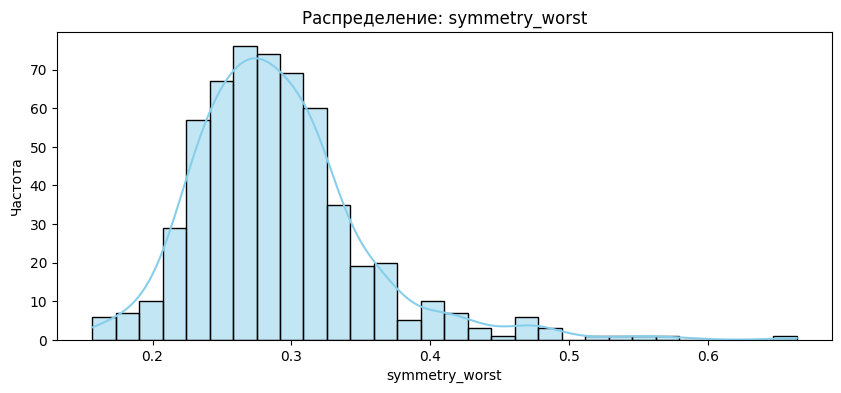

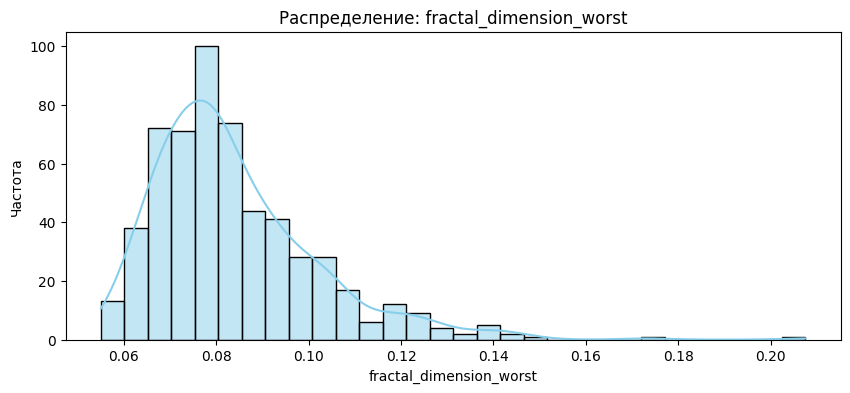

In [41]:
numerical = df.columns[2:-1]  # Все числовые признаки (30 штук)

# Гистограммы
for col in numerical:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Распределение: {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

In [34]:
## Анализ диаграмм (по группам признаков, типичные паттерны для этого датасета):
## 
##     - Средние значения (_mean):
##         1) radius_mean: Правосторонне скошенные (хвост вправо). Пик около 12–14 для radius_mean. Хвост до 28 (большие опухоли). KDE показывает один
##         модальный пик, но асимметрию — злокачественные случаи тянут хвост. Для perimeter_mean, area_mean аналогично, только другие числа.
##            
##         2) texture_mean, smoothness_mean: Более нормальные (колоколообразные), пики около 18–20 и 0.09–0.1, но с небольшими хвостами  (выбросы в высоких значениях).
##             
##         3) compactness_mean, concavity_mean, concave points_mean: Скошенные вправо, много нулевых/малых значений (доброкачественные клетки гладкие), 
##         хвосты для нерегулярных форм.
## 
##         4) symmetry_mean, fractal_dimension_mean: Близки к нормальным, пики около 0.18 и 0.06, минимальные хвосты.
## 
##     - Стандартные ошибки (_se):
##         1) radius_se, perimeter_se, area_se: Сильно скошенные вправо, пики около 0.2–0.4, длинные хвосты до 4–5 (высокая вариабельность в злокачественных).
##         KDE подчёркивает асимметрию.
##         
##         2) texture_se, smoothness_se: Более симметричные, но с хвостами (выбросы в ошибках измерений).
##         
##         3) compactness_se, concavity_se и прочие: Много малых значений, хвосты указывают на редкие большие вариации.
## 
##     - Худшие значения (_worst):
##         1) radius_worst: Скошенные вправо, пики около 13–15, хвосты до 30 (экстремальные размеры в M-классах). 
##         Аналогично , perimeter_worst, area_worst на с другими пиками и хвостами.
##             
##         2) texture_worst, smoothness_worst: Нормальные с лёгким скосом, пики около 25 и 0.13.
##             
##         3) compactness_worst, concavity_worst и все остальные: Хвосты вправо, указывающие на нерегулярность в худших клетках опухоли.
## 
## 
## Общие выводы:
##     - Большинство признаков скошены вправо (mean > median из df.describe()), указывая на наличие выбросов (большие клетки в M-классах).
##     - Признаки с сильными хвостами (radius, area) вероятно дискриминируют классы (M имеет большие значения) — это видно по пикам.
##     - данные неоднородны, с фокусом на экстремальных значениях для злокачественных случаев

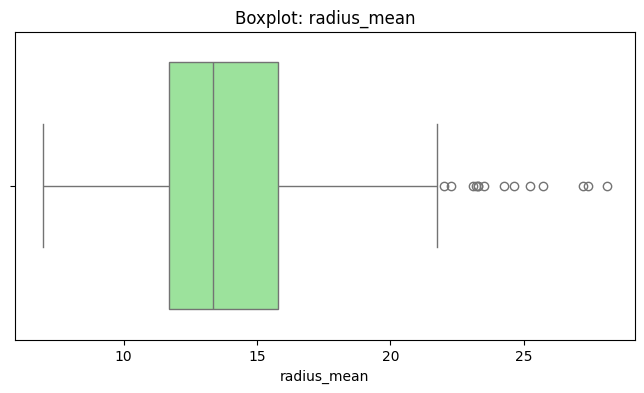

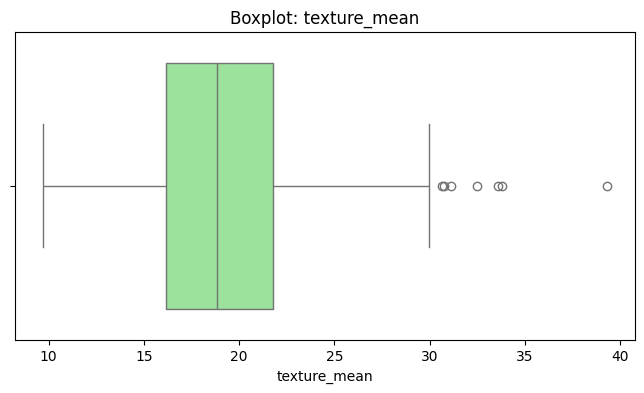

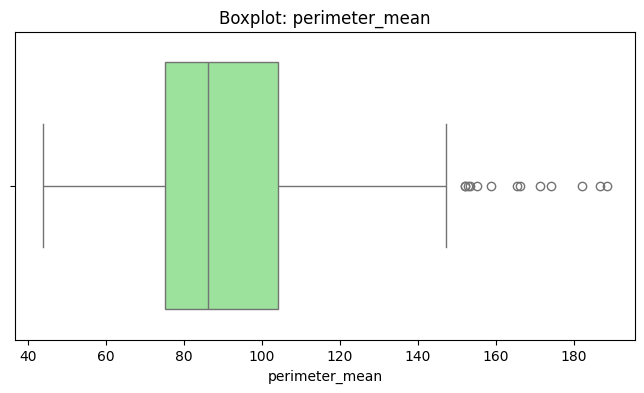

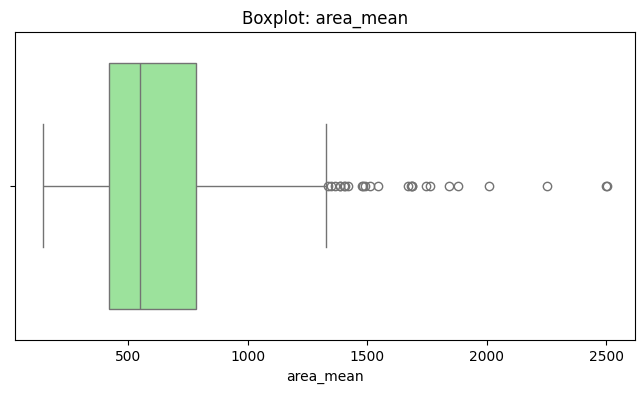

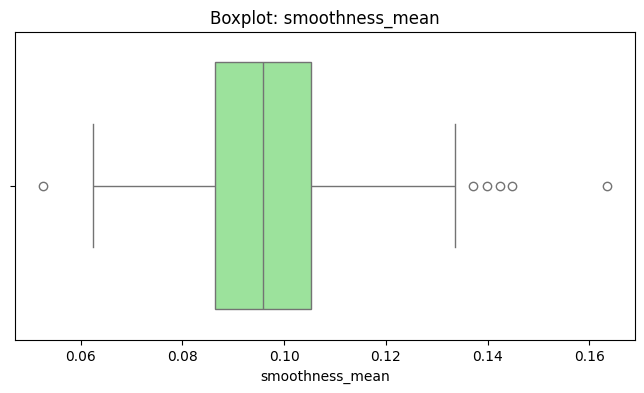

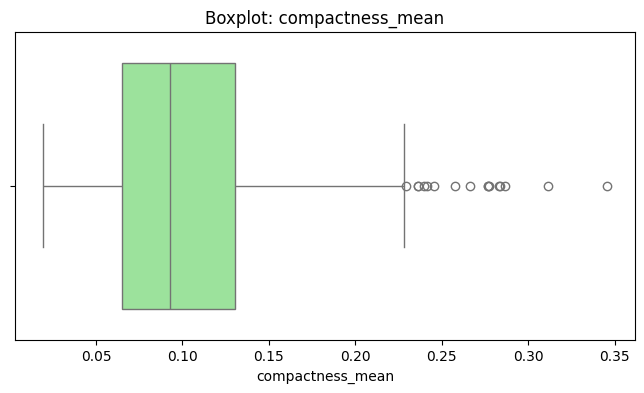

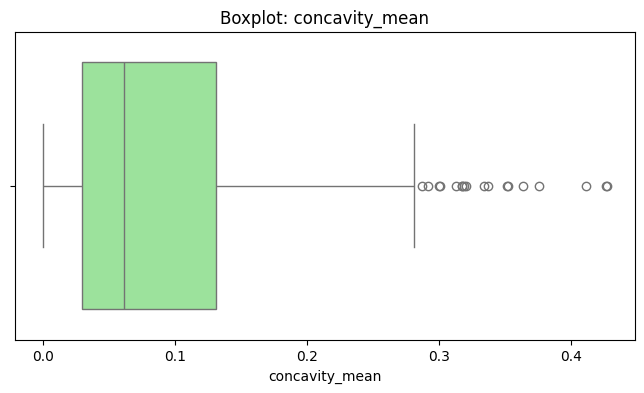

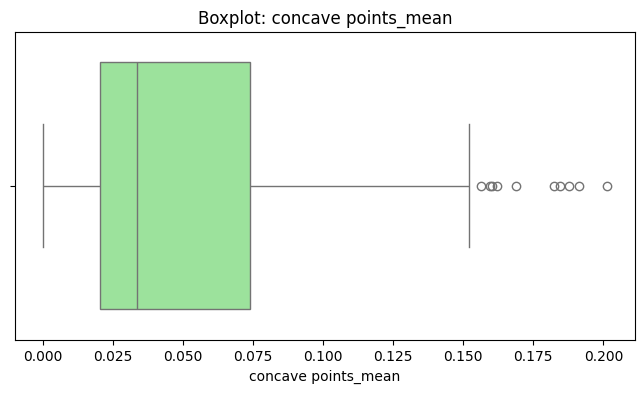

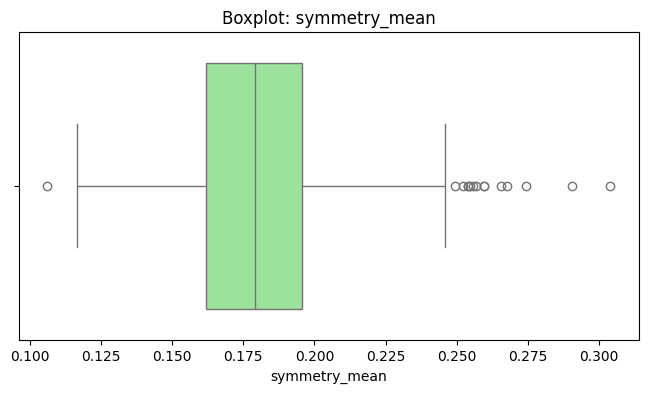

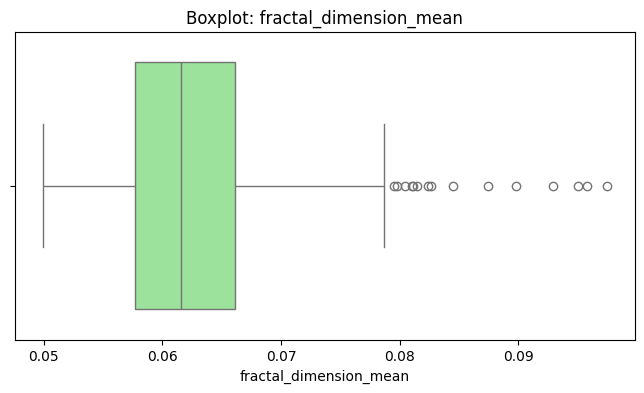

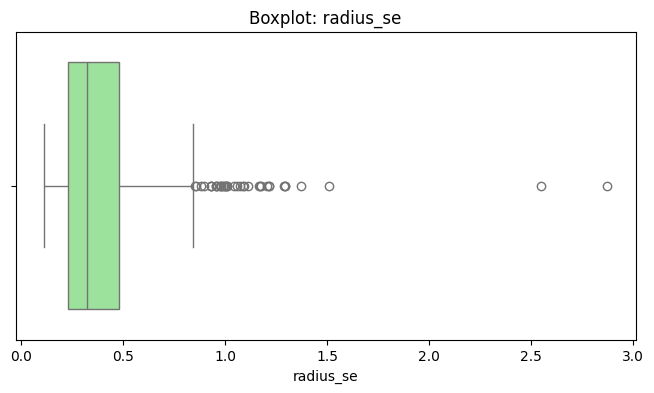

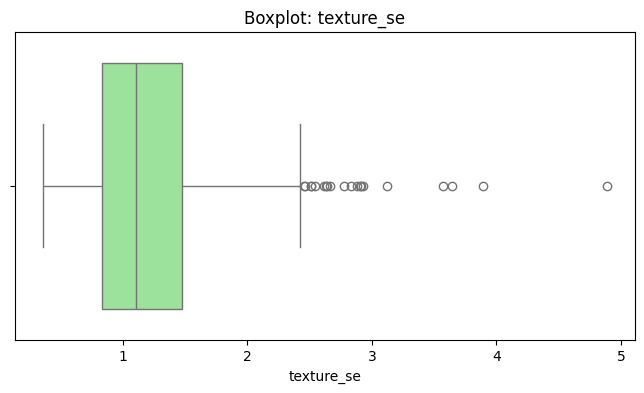

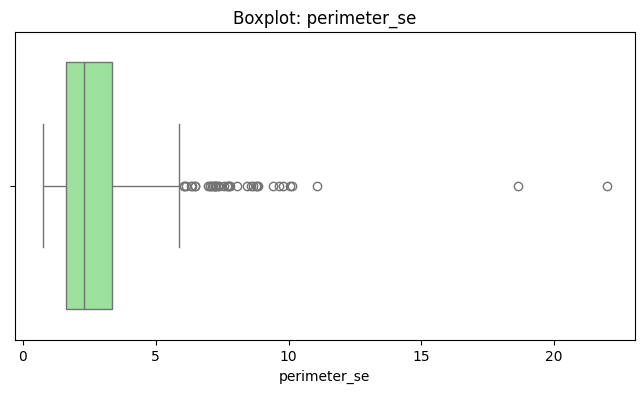

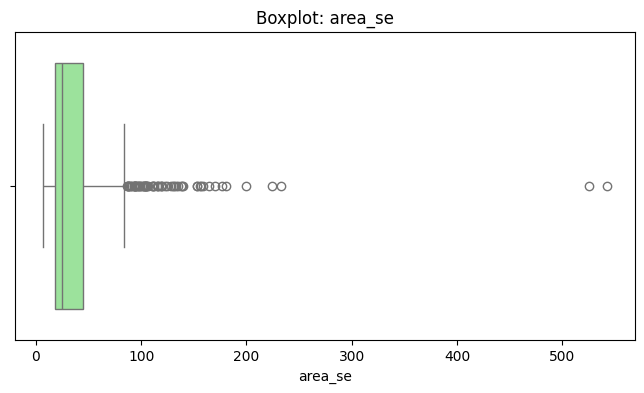

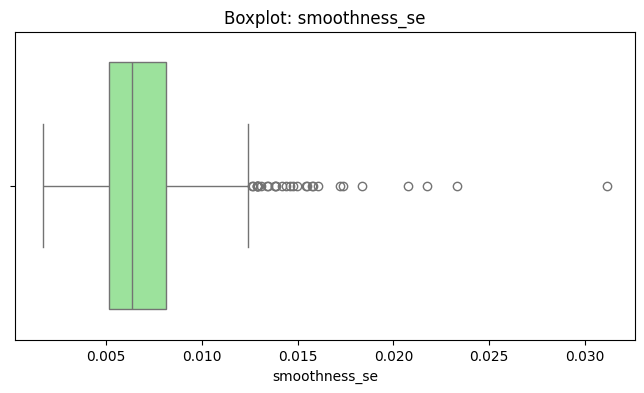

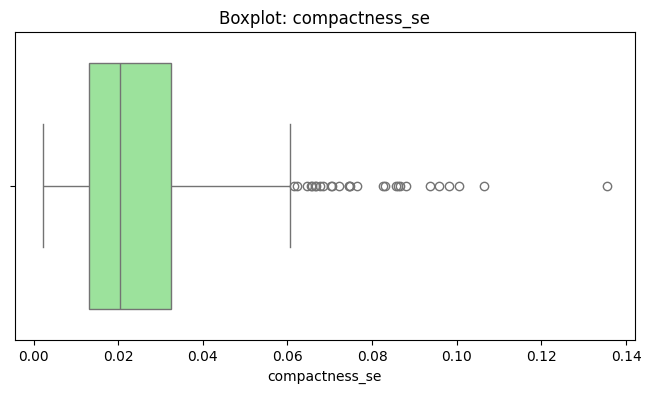

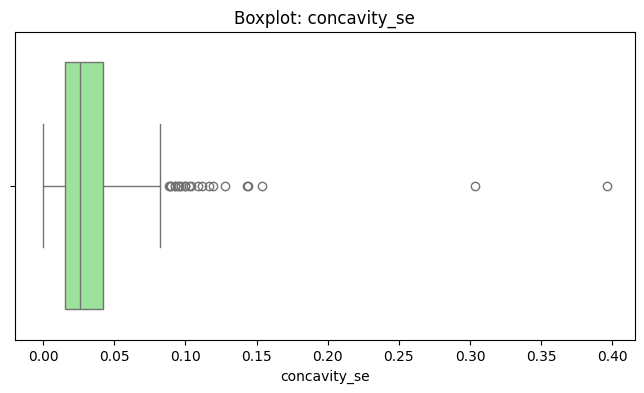

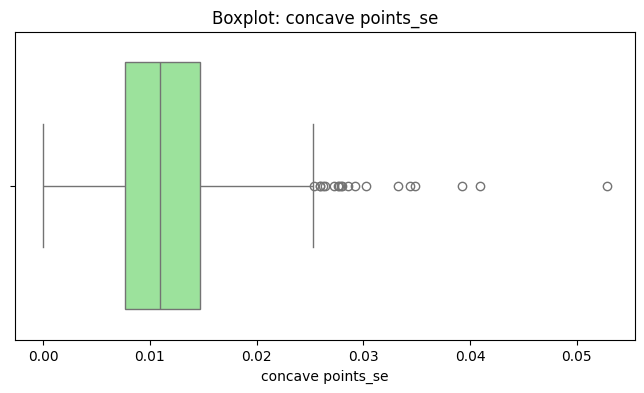

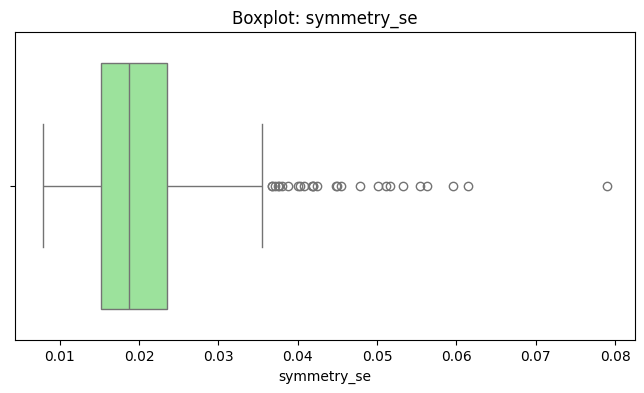

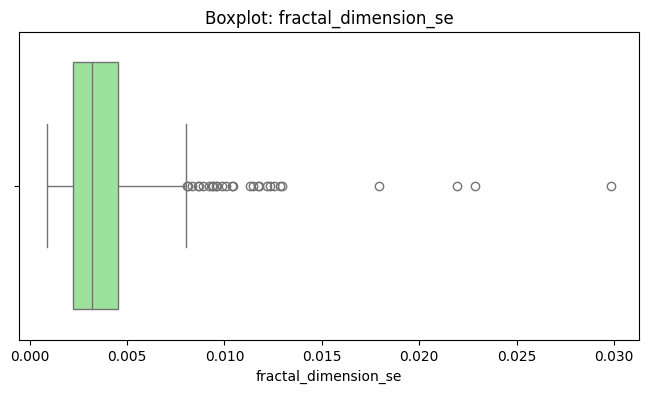

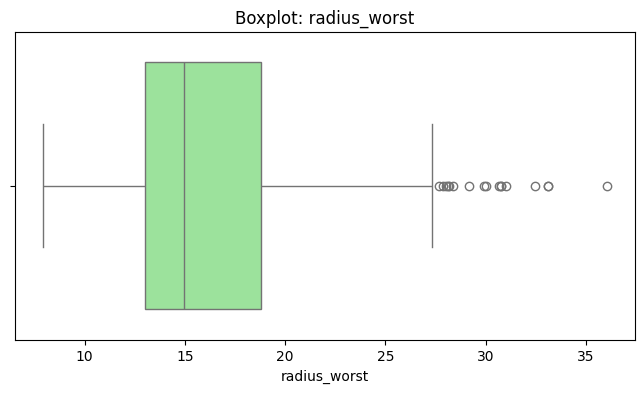

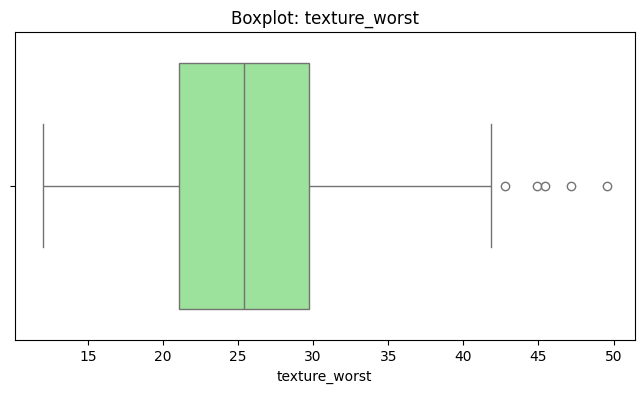

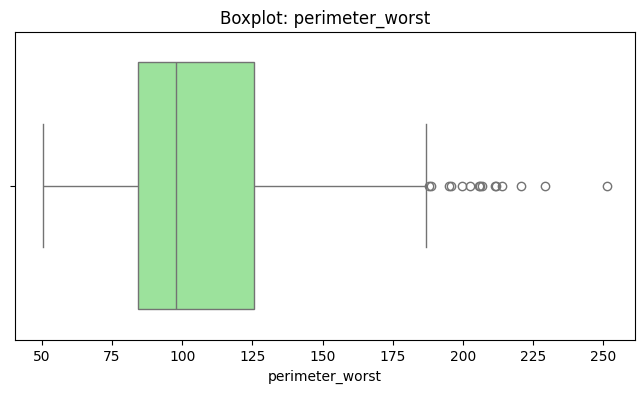

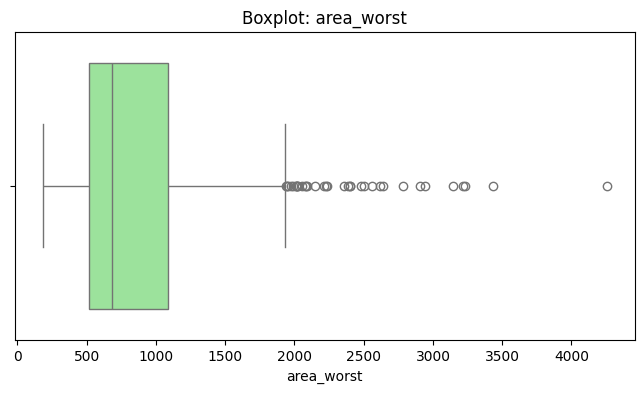

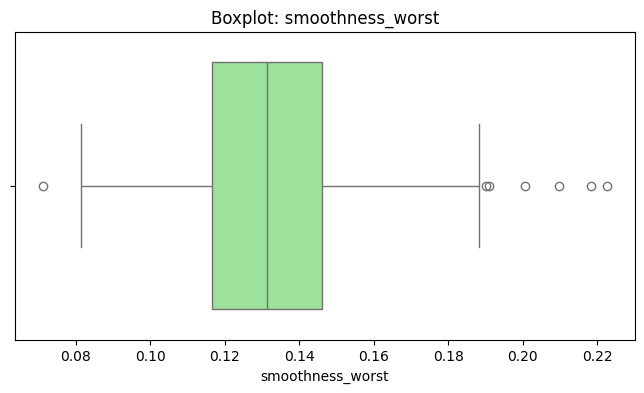

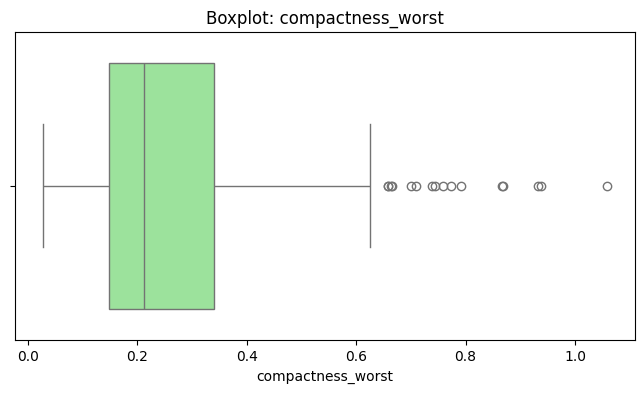

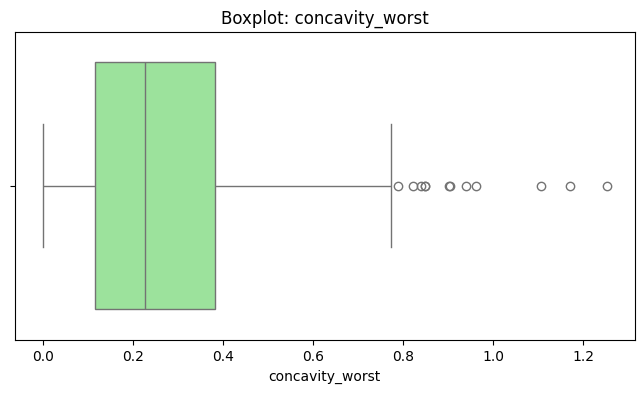

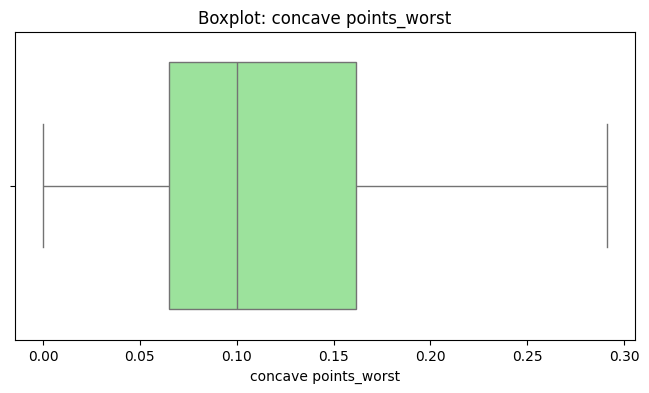

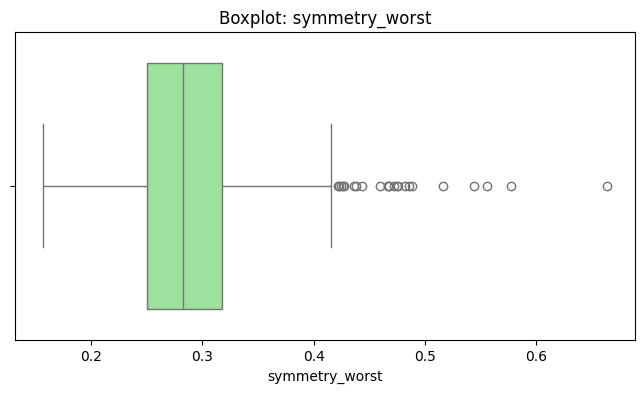

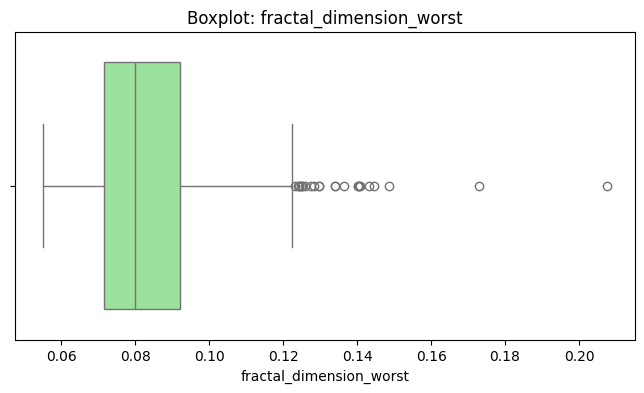

In [45]:
## построение boxplot (ящиков с усами)
for col in numerical:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot: {col}')
    plt.show()

In [44]:
## Анализ диаграмм
##
##     - Средние значения (_mean):
##         1) radius_mean, perimeter_mean, area_mean: Ящики относительно широкие (IQR ≈ 4–500), медиана смещена влево (асимметрия вправо). 
##         Усы длинные вправо, много точек-выбросов справа (большие значения, до 28/188/2501 — злокачественные опухоли). 
##            
##         2) texture_mean, smoothness_mean: Узкие ящики (малый IQR ≈ 4–0.02), медиана в центре (симметрия), 
##         редкие выбросы справа (7–6 штук, высокие текстуры/гладкость).
##             
##         3) compactness_mean, concavity_mean, concave points_mean: Смещённые медианы (влева), длинные верхние усы, 10–18 выбросов 
##         (нерегулярные формы в M-классах).
## 
##         4) symmetry_mean, fractal_dimension_mean: Симметричные ящики, минимальные усы, 15 выбросов справа (высокая симметрия/фрактальность).
## 
##     - Стандартные ошибки (_se):
##         1) radius_se, perimeter_se, area_se: Очень скошенные вправо, короткие левые усы (много малых значений), длинные правые с 
##         кластерами точек-выбросов (38–65 штук, самые большие — вариабельность в злокачественных). Ящики узкие, медиана сильно смещена влева.
##         
##         2) texture_se, smoothness_se: Симметричные, но с хвостами выбросов (20–30 штук, ошибки измерений).
## 
##         3) compactness_se, concavity_se и прочие.: Похожи на _mean, 19–28 выбросов (вариации форм).
##    
##     - Худшие значения (_worst):
##         1) radius_worst, perimeter_worst, area_worst: Широкие ящики (IQR ≈ 5–1000), сильная асимметрия вправо, много выбросов справа
##         (15–35 штук, экстремальные размеры в M).
##             
##         2) texture_worst, smoothness_worst: Узкие, симметричные, редкие выбросы (5–7 штук).
##             
##         3) compactness_worst, concavity_worst и т.д.: Смещённые, 12–24 выброса (нерегулярность в худших клетках).
## 
## 
## Общие выводы:
##     - Большинство boxplot показывают асимметрию (медиана ближе к левой границе ящика), длинные усы справа и точки-выбросы справа (положительный скос, как в гистограммах). 
##     - Нет выбросов слева (данные ≥0).
##     - Широкие ящики в _worst и _se показывают высокую вариабельность (std из describe()), асимметрия подтверждает скос вправо из гистограмм


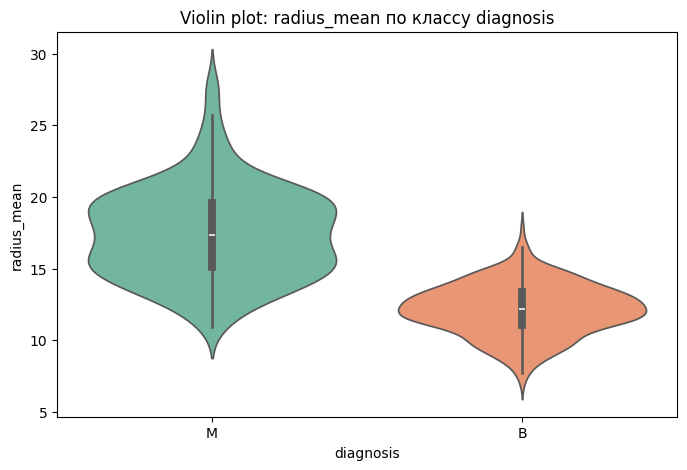

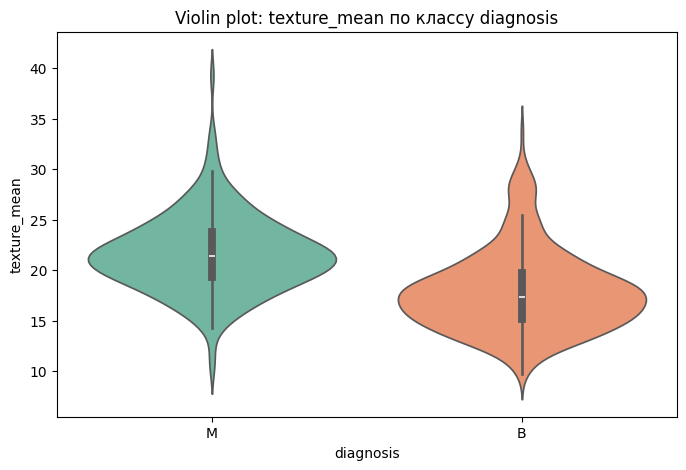

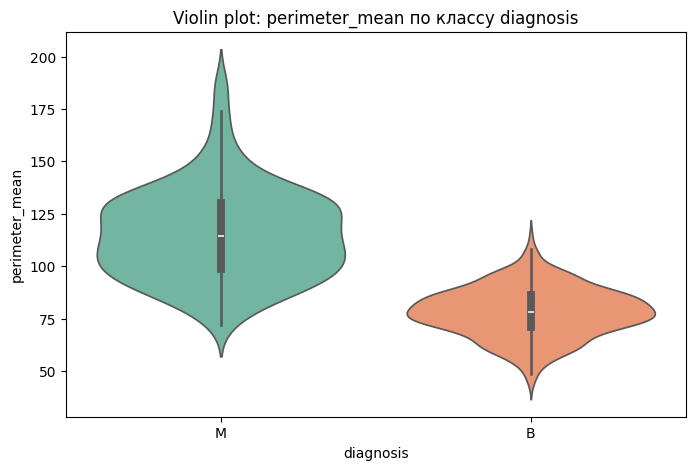

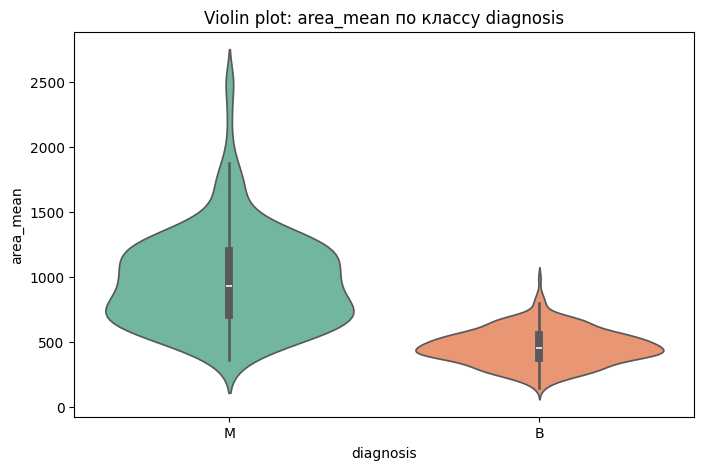

In [39]:
## построение violin plot (скрипичных диаграмм)
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
for col in key_features:
    plt.figure(figsize=(8, 5))
    sns.violinplot(x='diagnosis', y=col, data=df, hue='diagnosis', palette='Set2', legend=False)
    plt.title(f'Violin plot: {col} по классу diagnosis')
    plt.show()

In [47]:
## Анализ диаграмм
##    1) radius_mean (средний радиус): Две "скрипки" — справа B (доброкачественные: узкая, пик около 12, низкая плотность вверху), слева M 
##    (злокачественные: шире, пик около 17–18, хвост вверх до 28). Для B медиана ≈11.7, IQR узкий (10–13).
##    Для M медиана ≈17.5, IQR широкий (15–20), с верхними усами и выбросами. Плотность показывает перекрытие, но M смещено вверх.
##
##    2) texture_mean (средняя текстура): B: узкая скрипка, пик ≈17–18, симметричная. M: шире, пик ≈21–22, хвост вверх до 39. 
##    B медиана ≈16.2, IQR 14–18; M медиана ≈21.8, IQR 19–24, редкие выбросы. Плотность M более плоская, указывая на вариабельность.
##
##    3) perimeter_mean (средний периметр): Похоже на radius: B узкая (пик ≈75, медиана ≈75.2, IQR 65–85).
##    M широкая (пик ≈115, медиана ≈114, IQR 100–130), хвост до 188, верхние выбросы. Сильное разделение: минимальное перекрытие плотностей.
##
##    4) rea_mean (средняя площадь): B: узкая, пик ≈400, медиана ≈420, IQR 350–500; M: очень широкая, пик ≈900, медиана ≈932, IQR 700–1200, 
##    длинный хвост до 2500, много верхних выбросов. Плотность M растянута, показывая экстремальные значения.
##
## Выводы
##    - Violin показывают, что M-класс имеет более высокие значения и большую вариабельность (широкие скрипки, хвосты вправо) по размерам 
##    (radius, perimeter, area), texture тоже выше. Это подтверждает асимметрию из гистограмм/boxplot и статистики df.describe() (mean M > mean B).
##
##    - верхние выбросы в M (экстремальные опухоли), IQR шире для M (больше разброс).

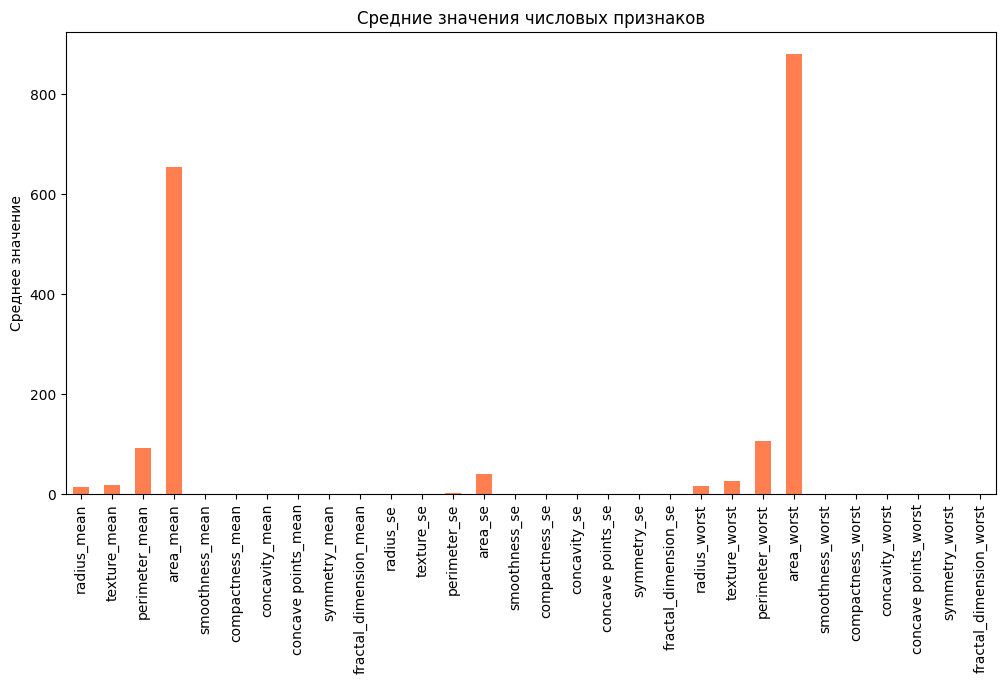

In [19]:
means = df[numerical].mean()
plt.figure(figsize=(12, 6))
means.plot(kind='bar', color='coral')
plt.title('Средние значения числовых признаков')
plt.ylabel('Среднее значение')
plt.xticks(rotation=90)
plt.show()

In [48]:
## Выводы
##
##    - Диаграмма подчёркивает различия в масштабах (area/perimeter >> smoothness/fractal) — признаки нуждаются в стандартизации для моделей
##    - Большие средние в _worst (≈880 для area) указывают на экстремальность в данных, согласуясь с выбросами из boxplot/violin.
##    - Средние подтверждают df.describe() и гистограммы: высокие для размеров (area_mean ≈655 — типичные опухоли средние), низкие для форм 
##    (concavity_mean ≈0.09 — большинство клеток гладкие). 
##    - Асимметрия не видна, но бары помогают выявить доминирующие признаки(worst area, mean area - основные, 
##    worst perimeter, mean perimeter, area error, worst texture, mean texture, worst radius, mean radius, perimeter error - доминируют в меньшей 
##    степени чем упомянутые ранее)
##    - Признаки с большими средними (area, perimeter) вероятно коррелируют с диагнозом (M выше, как в violin)

In [49]:
## 4. Двумерный анализ данных

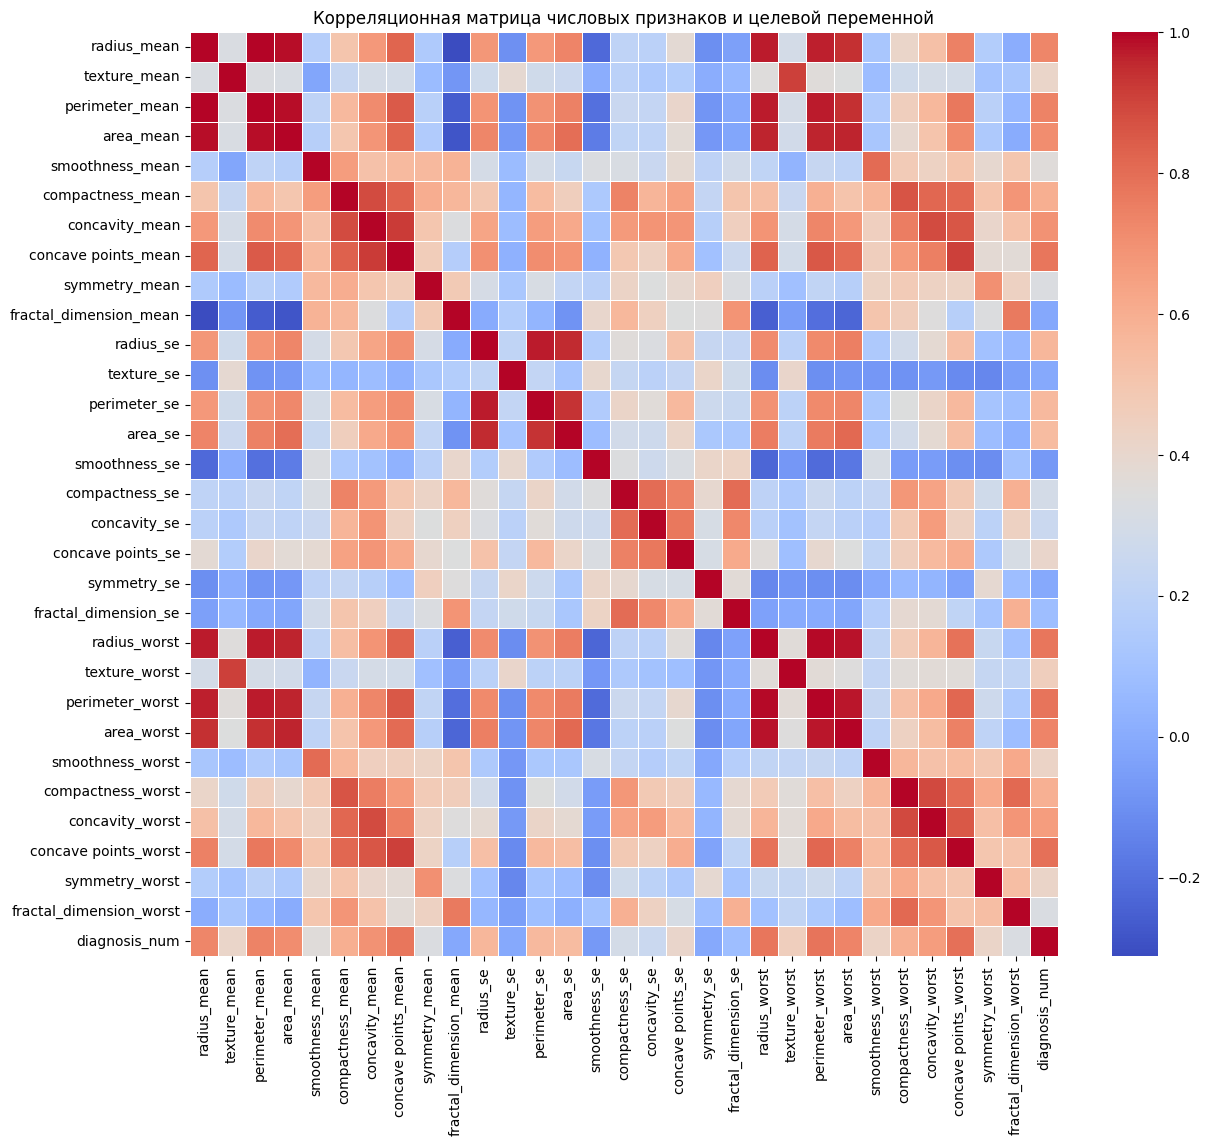

In [60]:
## построение тепловой карты (heatmap) для визуализации корреляций между числовыми признаками и целевой переменной
plt.figure(figsize=(14, 12))
corr_matrix = df[numerical.tolist() + ['diagnosis_num']].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков и целевой переменной')
plt.show()

In [48]:
## Анализ
##    - Сильные положительные (красный, >0.7): Кластеры между похожими — radius_mean/perimeter_mean/area_mean (≈0.99 — мультиколлинеарность размеров).
##     _worst с _mean (0.8–0.95); concave points_mean/concavity_mean (≈0.91 — форма связана).
##          
##    - Умеренные (оранжевый, 0.4–0.7): symmetry_mean с другими _mean; _se с _mean (вариации коррелируют с средними).
## 
##    - Слабые/отрицательные (синий, <0.4 или отриц.): fractal_dimension_mean с размерами (-0.3– -0.5 — фрактальность обратно пропорциональна размеру).
##     мало отрицательных (данные положительные).
##
##    - С 'diagnosis_num': Красные для worst_radius/perimeter/area/concave points (0.75–0.79 — сильная связь с злокачественностью).
##    оранжевые для mean_radius/area (≈0.73); синие для fractal_dimension/smoothness_se (≈0.01–0.2, слабая).
## Выводы
##    - Высокие положительные в группах (radius/perimeter/area ≈1) указывают на мультиколлинеарность — признаки redundant. Слабые/отрицательные (fractal с размерами) — независимые.
##    - Сильные (>0.7) для worst/mean размеров/формы (radius_worst ≈0.78) — эти атрибуты ключевые для классификации.
##    - Heatmap подтверждает асимметрию/выбросы (сильные корреляции в хвостах из violin/boxplot). Нет отрицательных с диагнозом — все положительные (большие значения = M).

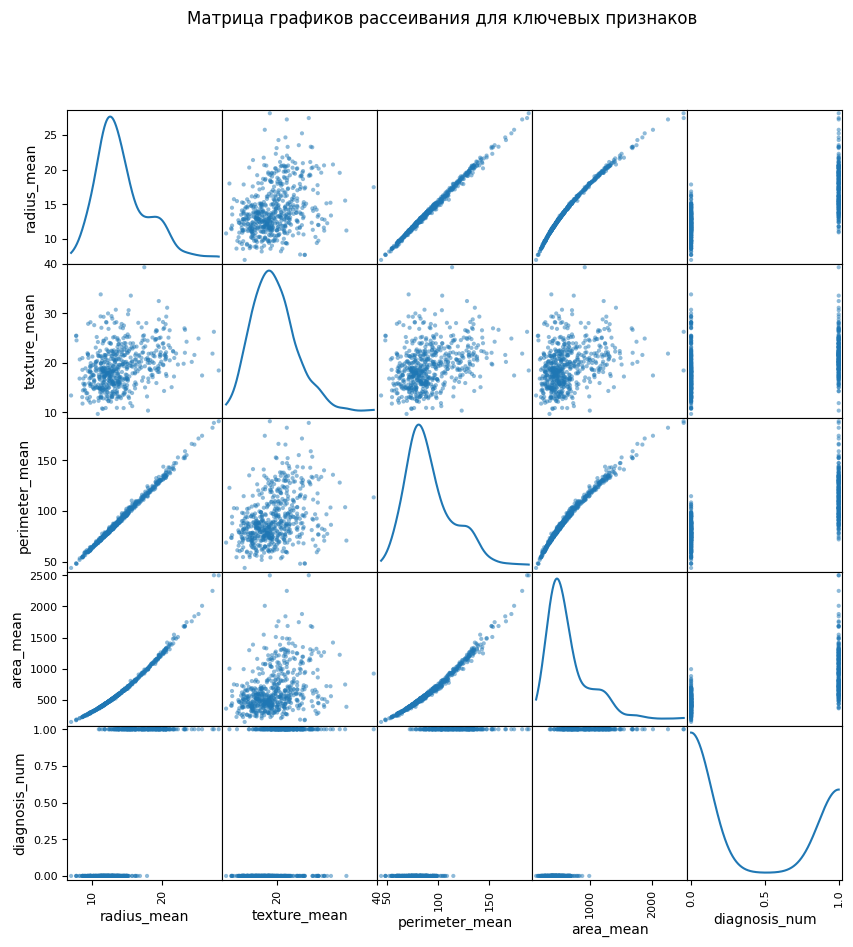

In [22]:
scatter_matrix(df[key_features + ['diagnosis_num']], figsize=(10, 10), diagonal='kde')
plt.suptitle('Матрица графиков рассеивания для ключевых признаков')
plt.show()

In [48]:
## Анализ диаграмм
##    - radius vs perimeter/area: Тесные линии (корреляция >0.99 — почти линейная).
##          
##    - radius vs texture: Рассеянные точки, слабая положительная (r≈0.32).
## 
##    - radius vs diagnosis_num Горизонтальные линии на 0/1, M (1) имеет более высокие значения (кластеры справа/сверху). Перекрытие, но разделение (M выше).
##
##    - Общий паттерн: Положительные корреляции (точки вверх-вправо) в размерах, слабые с texture/diagnosis. Точки кластеризуются по классам (B низко, M высоко).
## 
## Выводы
##    - Подтверждает heatmap (сильные между размерами: radius/perimeter/area — линейные; слабые с texture). С diagnosis_num — положительная (высокие значения = M, r≈0.73 для area). Это выявляет мультиколлинеарность
##    - KDE повторяет гистограммы/violin (скос в размерах, бимодальное для класса).

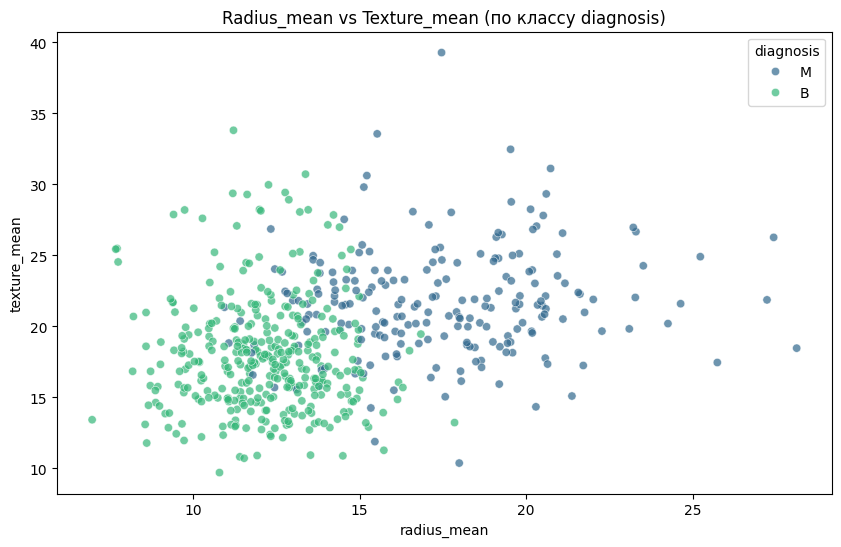

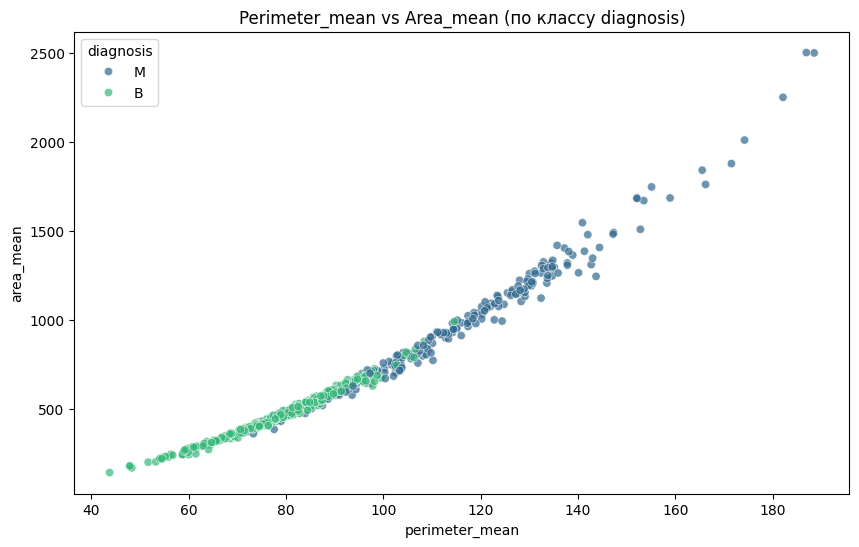

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='radius_mean', y='texture_mean', hue='diagnosis', alpha=0.7, palette='viridis')
plt.title('Radius_mean vs Texture_mean (по классу diagnosis)')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='perimeter_mean', y='area_mean', hue='diagnosis', alpha=0.7, palette='viridis')
plt.title('Perimeter_mean vs Area_mean (по классу diagnosis)')
plt.show()

In [48]:
## Анализ диаграмм
##    - Первая (radius_mean vs texture_mean): Рассеянный облако, слабый положительный тренд. 
##     Кластеры: B компактный (radius 8–15, texture 10–25), M растянутый (15–28, 15–35). Перекрытие ~30%, но M смещено вправо/вверх.
##     Viridis раскраска: тёмные для B, светлые для M.
##          
##    - Вторая (perimeter_mean vs area_mean): Тесная линия (почти y~x^2, но корреляция высокая). B внизу (perimeter 50–90, area 200–600), 
##    M сверху (100–190, 700–2500). Минимальное перекрытие, чёткое разделение. Alpha показывает плотность в кластерах.
## 
## Выводы
##    - Корреляции: Первая пара — слабая (рассеянность), вторая — сильная (линия), подтверждает heatmap. Hue выявляет разделение (M выше — злокачественные больше/нерегулярнее).
##    - Чёткое разделение в размерах (perimeter/area), слабее в texture/radius — признаки полезны для классификации
##    - Перекрытия — не все пары идеальны.
##    - Диаграммы подтверждают асимметрию/выбросы (M в хвостах), подходящие для моделей.

In [50]:
## подсчёта количества выбросов по правилу 1.5 × IQR
def count_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

print("Количество выбросов:")
for col in numerical:
    print(f'{col}: {count_outliers(col)}')

Количество выбросов:
radius_mean: 14
texture_mean: 7
perimeter_mean: 13
area_mean: 25
smoothness_mean: 6
compactness_mean: 16
concavity_mean: 18
concave points_mean: 10
symmetry_mean: 15
fractal_dimension_mean: 15
radius_se: 38
texture_se: 20
perimeter_se: 38
area_se: 65
smoothness_se: 30
compactness_se: 28
concavity_se: 22
concave points_se: 19
symmetry_se: 27
fractal_dimension_se: 28
radius_worst: 17
texture_worst: 5
perimeter_worst: 15
area_worst: 35
smoothness_worst: 7
compactness_worst: 16
concavity_worst: 12
concave points_worst: 0
symmetry_worst: 23
fractal_dimension_worst: 24


In [48]:
## Анализ вывода
##    - Самое большое количество — в признаках ошибок (area_se: 65, radius_se/perimeter_se: 38) и худших значений (area_worst: 35, symmetry_worst: 23). Это согласуется с boxplot (длинные верхние усы) и violin (хвосты в M-классе).
##          
##    - Меньше всего — в concave points_worst (0–2), texture_worst (5), smoothness_mean/worst (6–7) — эти признаки более "спокойные".
## 
## Выводы
##    - выбросы есть почти во всех 30 признаках(кроме concave points_worst). В smoothness_worst и texture_worst их очень мало

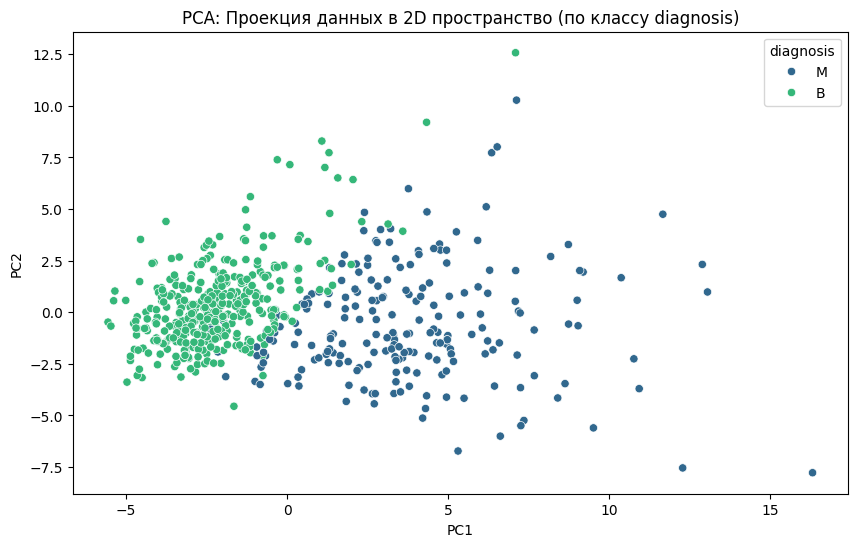

Доля объяснённой дисперсии: [0.44272026 0.18971182]


In [25]:
# Стандартизация и PCA
X = df[numerical]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['diagnosis'], palette='viridis')
plt.title('PCA: Проекция данных в 2D пространство (по классу diagnosis)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print(f'Доля объяснённой дисперсии: {pca.explained_variance_ratio_}')

In [48]:
## Выводы
##   - Два чётких кластера (B и M) с небольшим перекрытием — признаки хорошо разделяют диагноз. 
##    Злокачественные опухоли (M) имеют высокие значения по PC1 (размеры) и PC2 (форма/текстура). Это подтверждает, что 30 признаков содержат информацию о классе
##   - ~63% дисперсии объяснено двумя компонентами — приемлемо для визуализации (но для модели лучше 5–10 PC). Остальные 37% — шум или менее важные вариации.
##   - PCA подтверждает мультиколлинеарность (heatmap) и выбросы (M в хвостах). Классы разделены линейно в 2D — хорошая основа для классификаторов

In [ ]:
## Ответы на вопросы лабораторной работы
##
## 1. Есть ли выбросы в данных? Если да, укажите в каких атрибутах.**
##
## Да, выбросы присутствуют почти во всех 30 числовых признаках (кроме concave points_worst, где их 0–2).  
##
## Подсчёт по правилу 1.5 × IQR (реализован в функции count_outliers и подтверждён boxplot-ами):  
##    - Самое большое количество выбросов:  
##           - area_se — 65  
##           - radius_se, perimeter_se — по 38  
##           - area_worst — 35  
##           - fractal_dimension_se, compactness_se — по 28  
##           - symmetry_se, fractal_dimension_se — по 27–28  
##           - concavity_se — 22  
##           - symmetry_worst — 23  
##           - Меньше всего: texture_worst (5), smoothness_mean/worst (6–7), concave points_worst (≈0).  
##
## Обоснование: 
##    - Выбросы видны на boxplot (точки за усами), violin plot (длинные хвосты в M-классе), гистограммах (правосторонний скос).  
##    - Подтверждено df.describe(): max сильно превышает Q3 + 1.5×IQR, особенно в _se и _worst (area_se max ≈ 542, Q3 ≈ 48 → много выбросов).  
##    - Выбросы преимущественно верхние (большие значения) и связаны с злокачественными опухолями (M-класс), где клетки крупнее, нерегулярнее и вариабельнее (violin и scatter показывают хвосты M вправо).  
##
## 2. Есть ли переходный период?
##
## Нет, переходного периода нет.  
##
## Обоснование:
##    - Датасет Breast Cancer Wisconsin — это статические медицинские данные (569 образцов биопсии), а не временной ряд (нет столбца времени).  
##    - Каждый ряд — независимый замер характеристик клеток одной опухоли. Нет последовательности событий или перехода системы из одного состояния в другое.
##    - Это не CPS (киберфизическая система) с динамикой, а классический табличный датасет для классификации.
##
## 3. Какие атрибуты наиболее интересны для решения задачи классификации? Объясните почему.
##
## Наиболее интересные и информативные атрибуты (по силе связи с диагнозом и визуальному разделению классов):  
##
##    1. worst-контурные признаки (worst radius, worst perimeter, worst area, worst concave points) — корреляция с diagnosis_num ≈ 0.75–0.79 (heatmap).  
##    2. mean-контурные признаки (mean radius, mean perimeter, mean area, mean concave points) — корреляция ≈ 0.70–0.73.  
##    3. concave points_mean и concave points_worst — очень сильная связь (≈0.77–0.79), мало выбросов.  
##    4. compactness_mean/worst, concavity_mean/worst — корреляция ≈ 0.5–0.7.  
##
## Обоснование: 
##    - Корреляция с diagnosis_num (heatmap): самые высокие значения именно у worst/mean размеров и формы (radius/perimeter/area/concave points) — >0.7.  
##    - Scatter plot и violin plot: чёткое разделение B и M (M имеет большие значения, хвосты вправо). Например, perimeter_mean vs area_mean — почти линейная зависимость и минимальное перекрытие классов.  
##    - PCA (2D-проекция): два чётких кластера B и M с небольшим перекрытием -> признаки сохраняют информацию о классе даже в 2D (объяснено ~63% дисперсии).  
##    - Boxplot и гистограммы: M-класс имеет более высокие медианы, IQR и выбросы именно по этим признакам (большие/нерегулярные клетки = злокачественные).  
##
##Эти атрибуты наиболее интересны, потому что:  
##    - сильно коррелируют с целевой переменной (diagnosis),  
##    - дают визуальное разделение классов (scatter/violin/PCA),  
##    - отражают биологическую суть (размер и форма ядер клеток — ключевые маркеры злокачественности).  
## Остальные (_se, texture, fractal_dimension) имеют слабую корреляцию (<0.4) и хуже разделяют классы — они менее информативны.

In [ ]:
## 6. Вывод
## В ходе практической работы №1 выполнен полный разведочный анализ датасета Breast Cancer Wisconsin (Diagnostic) с использованием библиотеки Matplotlib и Seaborn.
##
##Основные результаты:
##    - Данные чистые: 569 записей, 30 числовых признаков + метка diagnosis, без пропусков.
##    - Одномерный анализ (гистограммы, boxplot, violin, bar): большинство признаков скошены вправо, с верхними выбросами (особенно в _se и _worst). Выбросы реальны и связаны с M-классом.
##    - Двумерный анализ (heatmap, scatter matrix, scatter plot): сильная мультиколлинеарность между размерами (radius/perimeter/area ≈0.99), высокая корреляция с диагнозом у worst/mean контурных признаков (0.7–0.79).
##    - PCA: 2 компоненты объясняют ~63% дисперсии, классы B и M хорошо разделяются в 2D-пространстве.
##    - Преобразование данных: рекомендуется стандартизация (уже выполнена перед PCA) и возможная лог-трансформация для скоса.
##
## Итог:Датасет подходит для задачи бинарной классификации (M vs B). Ключевые признаки связаны с размерами и формой клеток — именно они лучше всего отличают злокачественные опухоли. Полученные визуализации и статистики дают полное понимание природы данных и позволяют обоснованно выбрать признаки для модели.